<h1>Replication — Lifetime prevalence of owner-reported medical conditions in the 25 most common dog breeds in the Dog Aging Project pack</h1>
https://www.frontiersin.org/journals/veterinary-science/articles/10.3389/fvets.2023.1140417/full#h13

<b>DATA</b> <br>
Forsyth et al. (2023) used an older version of the Dog Aging Project data release which is now unavailable, but specified it was "data collected from 27,541 dogs enrolled in the DAP Pack between December 26, 2019 and December 31, 2020." Filtering the 2022 Curated Data Release for data between these two dates, we find 27,460 rows and 35 columns. <br>

<b>BREED COMPARISON WITH FORSYTH ET AL. (2023)</b> <br>
The distribution of mixed vs purebred dogs in our dataset is slightly different than that of Forsyth et al. (2023). <br>
- We count 14277 mixed breed dogs (52.0%) and 13233 purebred dogs (48.0%), while Forsyth et al. (2023) counted 13,923 mixed breed dogs (50.6%) and 13618 purebred dogs (49.4%). We ploted a bar chart below to visualize this difference. <br>
- The top 25 most common pure breeds in our dataset are the same 25 that Forsyth et al. (2023) found, but in a slightly different order. 

In [1]:
import numpy as np
import pandas as pd
import math 
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import HTML, display # for bolding p-values
from openpyxl import Workbook
from openpyxl.styles import Font

In [2]:
!pip3 freeze > requirements.txt  # saving package requirements

In [3]:
# reading all of our datasets
dog_overview = pd.read_csv('DAP_2022_DogOverview_v1.0.csv', low_memory=False) # 43517 rows 35 cols
dog_owner = pd.read_csv('DAP_2022_HLES_dog_owner_v1.0.csv', low_memory=False) # 43517 rows 933 cols
health_conditions = pd.read_csv('DAP_2022_HLES_health_condition_v1.0.csv', low_memory=False) # 119271 rows 12 cols
cancer_conditions = pd.read_csv('DAP_2022_HLES_cancer_conditions_v1.0.csv', low_memory=False) # 2762 rows 90 cols

# filtering data to the rows included in Forsyth et al. 
# "...27,541 dogs enrolled in the DAP Pack between December 26, 2019 and December 31, 2020."
dog_overview['DAP_Pack_Date'] = pd.to_datetime(dog_overview['DAP_Pack_Date'], format='%Y-%m-%d')
df_overview = dog_overview.loc[(dog_overview['DAP_Pack_Date']>='2019-12-26') & (dog_overview['DAP_Pack_Date']<='2020-12-31')]
print(f"Dog overview: {len(df_overview)} rows, {df_overview.shape[1]} columns")
# removing rows with null values (there are none, but still)
null_columns = ["Age_Years_Class_at_HLES", "LifeStage_Class_at_HLES", "Weight_Class_10KGBin_at_HLES", "Sex_Class_at_HLES"]
df_overview_cleaned = df_overview.dropna(subset=null_columns).drop_duplicates()
df_overview = df_overview_cleaned
print(f"Cleaned dog overview: {len(df_overview)} rows, {df_overview.shape[1]} columns")

Dog overview: 27460 rows, 35 columns
Cleaned dog overview: 27460 rows, 35 columns


Number of mixed breed dogs (Non-AKC-Recognized): 14227
Number of purebred dogs (AKC-Recognized): 13233


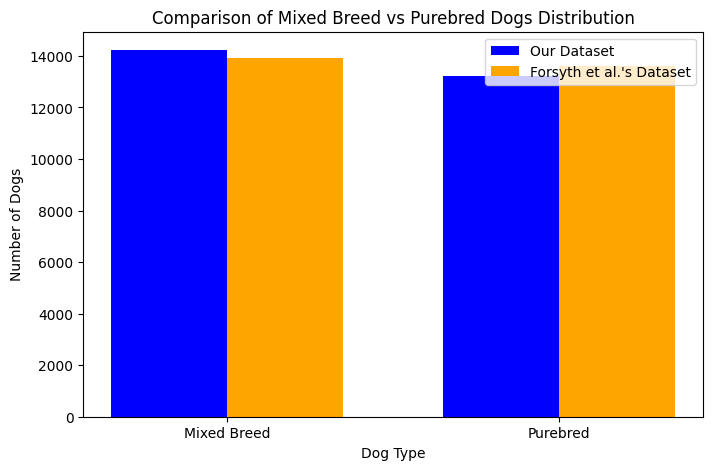

In [4]:
# number of mixed vs purebred dogs
mixed_pure_counts = df_overview['Breed_Class'].value_counts()
mixed_count = mixed_pure_counts.iloc[0]
pure_count = mixed_pure_counts.iloc[1]
print(f'Number of mixed breed dogs (Non-AKC-Recognized): {mixed_count}')
print(f'Number of purebred dogs (AKC-Recognized): {pure_count}')

# bar chart of our mixed vs. pure distribution compared to Forsyth et al.'s
forsyth_mixed_count = 13923
forsyth_pure_count = 13618
labels = ['Mixed Breed', 'Purebred']
bar_width = 0.35
x = range(len(labels))

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x, [mixed_count, pure_count], width=bar_width, label='Our Dataset', color='blue') # bars for our dataset
ax.bar([p + bar_width for p in x], [forsyth_mixed_count, forsyth_pure_count], width=bar_width, label="Forsyth et al.'s Dataset", color='orange') # bars for Forsyth et al.'s dataset, with an offset

ax.set_xlabel('Dog Type')
ax.set_ylabel('Number of Dogs')
ax.set_title('Comparison of Mixed Breed vs Purebred Dogs Distribution')
ax.set_xticks([p + bar_width / 2 for p in x])
ax.set_xticklabels(labels)
ax.legend()
plt.savefig("forsyth_comparison_breed_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# top 25 most common PURE dog breeds (Breed_Class has 'AKC-Recognized Breed' or 'Non-AKC-Recognized or Mixed Breed')
df_overview_purebred = df_overview[df_overview['Breed_Class'] == 'AKC-Recognized Breed']
purebred_counts = df_overview_purebred['Breed'].value_counts()
top_25_pure_counts = purebred_counts.head(25)
pd.set_option('display.max_rows', 50)
print(f"Top 25 most common pure breeds: {top_25_pure_counts}")

Top 25 most common pure breeds: Breed
Labrador Retriever               1663
Golden Retriever                 1455
German Shepherd Dog               603
Poodle                            464
Australian Shepherd               431
Dachshund                         341
Border Collie                     296
Chihuahua                         228
Beagle                            206
Pembroke Welsh Corgi              200
Boxer                             198
Shih Tzu                          193
Miniature Schnauzer               192
Pug                               188
Havanese                          180
Cavalier King Charles Spaniel     170
Yorkshire Terrier                 169
Great Dane                        163
Boston Terrier                    159
Greyhound                         159
Siberian Husky                    158
Shetland Sheepdog                 154
English Springer Spaniel          150
Australian Cattle Dog             145
Doberman Pinscher                 144
Name: count,

## TABLE 7 — DESCRIPTIVE DATA</b> 
We replicated Table 7 — Descriptive data for the DAP Pack including mixed-breed dogs, purebred dogs, and the 25 most popular individual breeds — from Forsyth et al. (2023). We plot the following columns by breed (total mixed, total pure, and the top 25 pure breeds): number of dogs, mean age, <b>mode</b> life stage, <b>mode weight class</b>, number of neutered males, number of intact males, number of spayed females, and number of intact females. <br>

NOTE: still need to implement: age range, mean weight??, weight range?? (bolded above = diff from Forsyth et al. (2023))

In [6]:
# function to create the table row for a given breed
def create_summary_row(df, breed_name, breed_df):
    total_dogs = breed_df.shape[0]
    age_mean = breed_df['Estimated_Age_Years_at_HLES'].mean()
    weight_class_mode = breed_df.mode()['Weight_Class_10KGBin_at_HLES'][0]
    life_stage_mode = breed_df.mode()['LifeStage_Class_at_HLES'][0]
    
    # count for each sex class
    female_intact_count = (breed_df['Sex_Class_at_HLES'] == 'Female, intact').sum()
    female_spayed_count = (breed_df['Sex_Class_at_HLES'] == 'Female, spayed').sum()
    male_intact_count = (breed_df['Sex_Class_at_HLES'] == 'Male, intact').sum()
    male_neutered_count = (breed_df['Sex_Class_at_HLES'] == 'Male, neutered').sum()
    # percentage for each class
    female_intact_percent = (female_intact_count / total_dogs) * 100
    female_spayed_percent = (female_spayed_count / total_dogs) * 100
    male_intact_percent = (male_intact_count / total_dogs) * 100
    male_neutered_percent = (male_neutered_count / total_dogs) * 100
    # format count and percentage in the same column
    male_neutered = f"{male_neutered_count} ({male_neutered_percent:.1f}%)"
    male_intact = f"{male_intact_count} ({male_intact_percent:.1f}%)"
    female_spayed = f"{female_spayed_count} ({female_spayed_percent:.1f}%)"
    female_intact = f"{female_intact_count} ({female_intact_percent:.1f}%)"
    
    return [
        breed_name, 
        total_dogs, 
        age_mean, 
        weight_class_mode,
        life_stage_mode, 
        male_neutered,
        male_intact, 
        female_spayed, 
        female_intact, 
    ]

# making the table
table_data = []
table_data.append(create_summary_row(df_overview, "Mixed-Breed Dogs", # mixed breed row
                                     df_overview[df_overview['Breed_Class'] == 'Non-AKC-Recognized or Mixed Breed']))
table_data.append(create_summary_row(df_overview, "Purebred Dogs (total)", # purebred row
                                     df_overview[df_overview['Breed_Class'] == 'AKC-Recognized Breed']))
top_25_pure_breed_names = purebred_counts.head(25).index.tolist() # top 25 pure breeds row
for breed in top_25_pure_breed_names:
    breed_df = df_overview[df_overview['Breed'] == breed]
    table_data.append(create_summary_row(df_overview, breed, breed_df))
columns = ["Breed", "Number of Dogs", "Mean Age (years)", "Weight Class (mode)", 
           "Life Stage (mode)", "Neutered Males [n (%)]", "Intact Males [n (%)]", 
           "Spayed Females [n (%)]", "Intact Females [n (%)]"]
df_table = pd.DataFrame(table_data, columns=columns)

# display
pd.set_option('display.max_columns', None) 
pd.set_option('display.expand_frame_repr', False)  # prevents wrapping to multiple lines
display(df_table)

,Breed,Number of Dogs,Mean Age (years),Weight Class (mode),Life Stage (mode),Neutered Males [n (%)],Intact Males [n (%)],Spayed Females [n (%)],Intact Females [n (%)]
0,Mixed-Breed Dogs,14227,7.381837,20-29.9,Mature Adult,6707 (47.1%),259 (1.8%),7112 (50.0%),149 (1.0%)
1,Purebred Dogs (total),13233,7.206612,20-29.9,Mature Adult,5709 (43.1%),1107 (8.4%),5815 (43.9%),602 (4.5%)
2,Labrador Retriever,1663,6.945941,30-39.9,Mature Adult,684 (41.1%),126 (7.6%),788 (47.4%),65 (3.9%)
3,Golden Retriever,1455,6.123711,30-39.9,Mature Adult,600 (41.2%),167 (11.5%),603 (41.4%),85 (5.8%)
4,German Shepherd Dog,603,5.949420,30-39.9,Mature Adult,210 (34.8%),67 (11.1%),295 (48.9%),31 (5.1%)
5,Poodle,464,7.223060,20-29.9,Mature Adult,229 (49.4%),38 (8.2%),183 (39.4%),14 (3.0%)
6,Australian Shepherd,431,6.592111,20-29.9,Mature Adult,199 (46.2%),33 (7.7%),176 (40.8%),23 (5.3%)
7,Dachshund,341,9.135777,0-9.9,Mature Adult,157 (46.0%),22 (6.5%),158 (46.3%),4 (1.2%)
8,Border Collie,296,7.366554,10-19.9,Mature Adult,114 (38.5%),21 (7.1%),143 (48.3%),18 (6.1%)
9,Chihuahua,228,9.734211,0-9.9,Mature Adult,108 (47.4%),5 (2.2%),104 (45.6%),11 (4.8%)


In [7]:
# excel_path = "table_7_descriptive_data.xlsx"

# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     df_table.to_excel(writer, sheet_name="Results", index=False)

#     workbook = writer.book
#     sheet = workbook.active
#     workbook.save(excel_path)

# print(f"Formatted Excel file saved to {excel_path}")

<b>MOST COMMON HEALTH CONDITIONS</b> <br>
The top 10 most common health conditions in each of the top 25 pure breeds add up to a list of 49 unique top health conditions: <br>
['Osteoarthritis', 'Murmur', 'Pancreatitis', 'Torn or broken toenail', 'Cataracts', 'Bordetella and/or parainfluenza (kennel cough)', 'Keratoconjunctivitis sicca (KCS)', 'Anal sac impaction', 'Retained deciduous (baby) teeth', 'Urinary crystals or stones in bladder or urethra', 'Pruritis (itchy skin)', 'Food or medicine allergies', 'Giardia', 'Sebaceous cysts', 'Dog bite', 'Hearing loss (incompletely deaf)', 'Coccidia', 'Patellar luxation', 'Intervertebral disc disease (IVDD) (Orthopedic)', 'Hypothyroidism (low thyroid function)', 'Corneal ulcer', 'Chronic or recurrent hot spots', 'Seasonal allergies', 'Fleas', 'Chronic kidney disease', 'Dental calculus (yellow build-up on teeth)', 'Fractured teeth', 'Underbite', 'Chocolate', 'Foreign body ingestion or blockage', 'Chronic or recurrent diarrhea', 'Roundworms', 'Lick granuloma', 'Stenotic/narrow nares', 'Extracted teeth', 'Entropion (eyelid rolled in)', 'Ear Infection', 'Hip dysplasia', 'Lyme disease', 'Deafness', 'Conjunctivitis', 'Seizures (including epilepsy)', 'Laceration', 'Tracheal collapse', 'Food or medicine allergies that affect the skin', 'Hookworms', 'Cruciate ligament rupture', 'Gingivitis (red, puffy gums)', 'Urinary incontinence']

In [8]:
hs_condition_values = [
    101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 
    116, 117, 118, 119, 120, 198, 201, 202, 203, 204, 205, 206, 207, 208, 209, 
    298, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 398, 
    401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415, 
    416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428, 429, 430, 
    431, 432, 498, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 
    513, 514, 515, 516, 518, 519, 598, 601, 602, 603, 604, 605, 606, 607, 608, 
    609, 610, 611, 612, 698, 701, 702, 703, 704, 705, 706, 707, 708, 709, 710, 
    711, 712, 713, 714, 715, 716, 717, 718, 719, 720, 721, 798, 801, 802, 803, 
    804, 805, 806, 807, 808, 809, 898, 901, 902, 903, 904, 905, 906, 907, 908, 
    909, 910, 911, 912, 913, 914, 915, 916, 998, 1001, 1002, 1003, 1004, 1005, 
    1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 
    1098, 1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1110, 1111, 
    1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119, 1198, 1201, 1202, 1203, 
    1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212, 1213, 1214, 1215, 
    1216, 1217, 1298, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 
    1310, 1311, 1312, 1398, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 
    1409, 1410, 1411, 1412, 1413, 1414, 1415, 1416, 1498, 1598, 1601, 1602, 
    1603, 1604, 1605, 1606, 1607, 1608, 1609, 1610, 1611, 1612, 1613, 1614, 
    1615, 1616, 1617, 1618, 1619, 1620, 1621, 1622, 1623, 1624, 1625, 1626, 
    1627, 1628, 1629, 1630, 1631, 1632, 1633, 1634, 1635, 1636, 1637, 1638, 
    1639, 1640, 1698, 1701, 1702, 1703, 1704, 1705, 1706, 1707, 1708, 1709, 
    1710, 1798, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810, 
    1811, 1812, 1813, 1814, 1815, 1816, 1817, 1898, 1901, 1902, 1903, 1904, 
    1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1998
]

hs_condition_names = [
    "Blindness", "Cataracts", "Glaucoma", "Keratoconjunctivitis sicca (KCS)", "Persistent pupillary membrane (PPM)", 
    "Missing one or both eyes", "Third eyelid prolapse (cherry eye)", "Conjunctivitis", "Corneal ulcer", "Distichia", 
    "Ectropion (eyelid rolled out)", "Entropion (eyelid rolled in)", "Imperforate lacrimal punctum", "Iris cyst", 
    "Juvenile cataracts", "Nuclear sclerosis", "Pigmentary uveitis", "Progressive retinal atrophy", 
    "Retinal detachment", "Uveitis", "Other eye condition", "Deafness", "Ear Infection", "Ear Mites", 
    "Epistaxis (nose bleeds)", "Hearing loss (incompletely deaf)", "Hematoma", "Pharyngitis", "Rhinitis", 
    "Tonsillitis", "Other ear condition", "Cleft lip", "Cleft palate", "Missing teeth", 
    "Dental calculus (yellow build-up on teeth)", "Extracted teeth", "Fractured teeth", "Gingivitis (red, puffy gums)", 
    "Masticatory myositis", "Oronasal fistula", "Overbite", "Retained deciduous (baby) teeth", "Sialocele", 
    "Underbite", "Other oral condition", "Dermoid cysts", "Spina bifida", "Umbilical hernia (Skin)", 
    "Alopecia (hair loss)", "Atopic dermatitis (atopy)", "Chronic or recurrent hot spots", 
    "Chronic or recurrent skin infections", "Contact dermatitis", "Discoid lupus erythematosus (DLE) (Skin)", 
    "Flea allergy dermatitis", "Fleas", "Food or medicine allergies that affect the skin", "Ichthyosis", 
    "Lick granuloma", "Non-specific dermatosis", "Panepidermal pustular pemphigus (PPP) (Skin)", 
    "Paraneoplastic pemphigus (PNP) (Skin)", "Pemphigus erythematosus (PE) (Skin)", 
    "Pemphigus foliaceus (PF) (Skin)", "Pemphigus vulgaris (PV) (Skin)", "Pododermatitis", "Polymyositis (Skin)", 
    "Pruritis (itchy skin)", "Pyoderma or bacterial dermatitis", "Sarcoptic mange", "Seasonal allergies", 
    "Sebaceous adenitis", "Sebaceous cysts", "Seborrhea or seborrheic dermatitis (greasy skin)", 
    "Systemic demodectic mange", "Systemic lupus erythematosus (SLE) (Skin)", "Ticks", "Other skin condition", 
    "Aortic/Subaortic stenosis", "Atrial septal defects", "Mitral dysplasia", "Murmur", "Patent ductus arteriosus (PDA)", 
    "Persistent right aortic arch", "Pulmonic stenosis", "Tricuspid dysplasia", "Ventricular septal defects", 
    "Arrhythmia", "Cardiomyopathy", "Congestive heart failure", "Endocarditis", "Hypertension (high blood pressure)", 
    "Pericardial effusion", "Pulmonary hypertension", "Subaortic stenosis", "Valve disease", "Other Cardiac", 
    "Stenotic/narrow nares", "Tracheal stenosis (narrowing)", "Acquired or acute respiratory distress syndrome (ARDS)", 
    "Chronic or recurrent bronchitis", "Chronic or recurrent cough", "Chronic or recurrent rhinitis", 
    "Elongated soft palate", "Laryngeal paralysis (Respiratory)", "Lung lobe torsion", "Pneumonia", "Pulmonary bullae", 
    "Tracheal collapse", "Other respiratory condition", "Atresia ani", "Esophageal achalasia", "Megaesophagus", 
    "Umbilical hernia (Gastrointestinal)", "Anal sac impaction", "Bilious vomiting syndrome", "Bloat with torsion (GDV)", 
    "Chronic or recurrent diarrhea", "Chronic or recurrent vomiting", "Constipation", "Fecal incontinence", 
    "Food or medicine allergies", "Foreign body ingestion or blockage", "Hemorrhagic gastroenteritis (HGE) or stress colitis (acute)", 
    "Idiopathic canine colitis (chronic)", "Irritable bowel syndrome (IBS) or inflammatory bowel disease (IBD)", 
    "Lymphangiectasia", "Malabsorptive disorder", "Other allergies", "Protein-losing enteropathy (PLE)", 
    "Pyloric stenosis", "Other gastrointestinal condition", "Portosystemic shunt", "Biliary obstruction", 
    "Chronic inflammatory liver disease", "Exocrine pancreatic insufficiency (EPI)", "Gall bladder mucocele", 
    "Gall bladder rupture", "Gall bladder surgery", "Microvascular dysplasia (portal vein hypoplasia)", 
    "Pancreatitis", "Other liver condition", "Born with one kidney", "Ectopic ureter", "Patent urachus", 
    "Renal cysts", "Renal dysplasia", "Acute kidney failure", "Bladder prolapse", "Chronic kidney disease", 
    "Pyelonephritis (kidney infection)", "Kidney stones", "Proteinuria", "Tubular disorder (such as Fanconi syndrome)", 
    "Urethral prolapse", "Urinary crystals or stones in bladder or urethra", "Urinary incontinence", 
    "Urinary tract infection (chronic or recurrent)", "Other kidney condition", "Cryptorchid", "Hermaphroditism", 
    "Hypospadias", "Phimosis", "Benign prostatic hyperplasia", "Dystocia", "Irregular heat cycle", "Mastitis", 
    "Papilloma (genital warts)", "Paraphimosis", "Prostatitis", "Preputial infection", "Pseudopregnancy", 
    "Pyometra", "Recessed vulva", "Testicular atrophy", "Vaginitis", "Other reproductive condition", 
    "Missing a limb or part of a limb", "Valgus deformity", "Varus deformity", "Carpal subluxation syndrome", 
    "Cruciate ligament rupture", "Degenerative joint disease", "Dwarfism", "Elbow dysplasia", "Growth deformity", 
    "Hip dysplasia", "Intervertebral disc disease (IVDD) (Orthopedic)", "Lameness (chronic or recurrent)", 
    "Osteoarthritis", "Osteochondritis dissecans (OCD)", "Osteomyelitis", "Panosteitis", "Patellar luxation", 
    "Rheumatoid arthritis", "Spondylosis", "Other orthopedic condition", "Cerebellar hypoplasia", "Hydrocephalus", 
    "Cauda equina syndrome", "Degenerative myelopathy", "Dementia or senility", "Diskospondylitis", "Dysautonomia", 
    "Fibrocartilaginous embolism (FCE)", "Horner's syndrome", "Intervertebral disc disease (IVDD) (Neurologic)", 
    "Laryngeal paralysis (Neurologic)", "Limb paralysis", "Myasthenia gravis", "Polyneuropathy", 
    "Seizures (including epilepsy)", "Vestibular disease", "Wobbler syndrome", "Other neurologic condition", 
    "Congenital hypothyroidism", "Juvenile hypoglycemia", "Pituitary dwarfism", 
    "Addison's disease (hypoadrenocorticism; low adrenal function)", 
    "Cushing's disease (hyperadrenocorticism; excess adrenal function)", 
    "Diabetes insipidus (rare diabetes which causes water balance problems)", 
    "Diabetes mellitus (common diabetes which causes high blood sugar)", "Hypercalcemia (excess calcium in the blood)", 
    "Hyperparathyroidism (excess parathyroid function causing high calcium)", 
    "Hypoparathyroidism (low parathyroid function causing low calcium)", "Hyperthyroidism (excess thyroid function)", 
    "Hypothyroidism (low thyroid function)", "Other endocrine condition", "Congenital dyserythropoiesis", 
    "Macrothrombocytopenia", "Microcytosis or macrocytosis", "Pelger-Huet anomaly", 
    "Phosphofructokinase (PFK) deficiency", "Pyruvate kinase (PK) deficiency", "Anemia", "Factor I deficiency", 
    "Hemophilia", "Polycythemia", "Selective IgM deficiency", "Splenic hematoma", "Splenic torsion", 
    "Thrombocytopenia (not immune-mediated)", "Thromboembolism", "Von Willebrand's disease", "Other Hematopoietic", 
    "Other congenital disorder", "Anaplasmosis", "Aspergillosis", "Babesiosis", "Blastomycosis", 
    "Bordetella and/or parainfluenza (kennel cough)", "Brucellosis", "Campylobacteriosis", "Chagas disease (trypanosomiasis)", 
    "Coccidia", "Coccidioidiomycosis", "Cryptococcus", "Dermatophytosis (ringworm)", "Distemper", "Ehrlichiosis", 
    "Fever of unknown origin", "Gastrointestinal parasites", "Giardia", "Granuloma", "Heartworm infection", 
    "Histoplasmosis", "Hepatozoonosis", "Hookworms", "Influenza", "Isospora", "Leishmaniasis", "Leptospirosis", 
    "Lyme disease", "MRSA/MRSP", "Mycobacterium", "Parvovirus", "Plague (Yersinia pestis)", "Pythium", 
    "Rocky Mountain Spotted Fever (RMSF)", "Roundworms", "Salmonellosis", "Salmon poisoning", "Tapeworms", 
    "Toxoplasma", "Tularemia", "Whipworms", "Other infectious disease", "Chocolate", "Ethylene glycol (antifreeze)", 
    "Grapes or raisins", "Ingestion of human medications", "Ingestion of recreational drugs", 
    "Mouse or rat bait/poison (Bromethalin)", "Mouse or rat bait/poison (Calciferol)", 
    "Mouse or rat bait/poison (Warfarin)", "Mouse or rat bait/poison (Other/Unknown)", 
    "Overdose of medications prescribed to the dog", "Other ToxinConsumption", "Dog bite", 
    "Bite wound from another animal", "Fall from height", "Fractured bone (long bone in limb)", 
    "Fractured bone (other bone in limb)", "Fractured bone (spine)", "Fractured bone (rib(s))", 
    "Fractured bone (flat bone of head or face)", "Head trauma due to any cause", "Hit by car or other vehicle", 
    "Kicked by horse or other large animal", "Laceration", "Penetrating wound (such as a stick)", 
    "Proptosis (eye out of socket)", "Snakebite", "Tail injury", "Torn or broken toenail", "Other trauma", 
    "Autoimmune thyroiditis", "Discoid lupus erythematosus (DLE) (Immune)", 
    "Idiopathic immune-mediated thrombocytopenia (IMT/ITP)", 
    "Immune-mediated hemolytic anemia (IMHA) or autoimmune hemolytic anemia (AIHA)", 
    "Immune-mediated polyarthritis (IMPA)", "Panepidermal pustular pemphigus (PPP) (Immune)", 
    "Paraneoplastic pemphigus (PNP) (Immune)", "Pemphigus erythematosus (PE) (Immune)", 
    "Pemphigus foliaceus (PF) (Immune)", "Pemphigus vulgaris (PV) (Immune)", "Polymyositis (Immune)", 
    "Systemic lupus erythematosus (SLE) (Immune)", "Other Immune"
]

In [9]:
# filtering out any health conditions that contain the word "other", case insensitive
filtered_conditions = [(value, name) for value, name in zip(hs_condition_values, hs_condition_names) if "other" not in name.lower()]
# unzipping the filtered conditions back into two separate lists
hs_condition_values_filtered, hs_condition_names_filtered = zip(*filtered_conditions)
# creating the dictionary by zipping the filtered lists together
hs_condition_dict = dict(zip(hs_condition_values_filtered, hs_condition_names_filtered))

# filtering df_overview for the top 25 pure dog breeds
df_overview_top_pure = df_overview[df_overview['Breed'].isin(top_25_pure_breed_names)]
# merging the top 25 pure breeds dog overview dataset with health conditions
df_overview_health = pd.merge(df_overview_top_pure[['dog_id', 'Breed']], health_conditions[['dog_id', 'hs_condition']], on='dog_id', how='inner')
# ensuring hs_condition values are integers and handling nan's
df_overview_health['hs_condition'] = df_overview_health['hs_condition'].dropna().astype(int)
# counting the frequency of each health condition by breed
condition_counts = df_overview_health.groupby(['Breed', 'hs_condition']).size().reset_index(name='count')
# mapping the numerical 'hs_condition' value to the text labels using the filtered hs_condition_dict dictionary
condition_counts['condition_label'] = condition_counts['hs_condition'].map(hs_condition_dict)
# handling any NaN values in the condition_label column by removing rows with NaN condition labels
condition_counts = condition_counts.dropna(subset=['condition_label'])

# getting the top 10 most common conditions for each breed
top_conditions_by_breed = condition_counts.groupby('Breed').apply(lambda x: x.nlargest(10, 'count'), include_groups=False).reset_index(drop=True)
# combining the top conditions into one list of text labels
combined_top_conditions_labels = top_conditions_by_breed['condition_label'].tolist()
# getting unique conditions across all breeds
top_49_health_conditions = list(set(combined_top_conditions_labels))

# output
print(f"{len(top_49_health_conditions)} Unique top conditions: {top_49_health_conditions}")

49 Unique top conditions: ['Bordetella and/or parainfluenza (kennel cough)', 'Sebaceous cysts', 'Anal sac impaction', 'Ear Infection', 'Urinary crystals or stones in bladder or urethra', 'Keratoconjunctivitis sicca (KCS)', 'Foreign body ingestion or blockage', 'Dental calculus (yellow build-up on teeth)', 'Food or medicine allergies that affect the skin', 'Hookworms', 'Pruritis (itchy skin)', 'Stenotic/narrow nares', 'Tracheal collapse', 'Coccidia', 'Chronic kidney disease', 'Hip dysplasia', 'Osteoarthritis', 'Roundworms', 'Chronic or recurrent hot spots', 'Murmur', 'Deafness', 'Chocolate', 'Urinary incontinence', 'Laceration', 'Corneal ulcer', 'Food or medicine allergies', 'Underbite', 'Conjunctivitis', 'Seasonal allergies', 'Pancreatitis', 'Fleas', 'Hearing loss (incompletely deaf)', 'Lyme disease', 'Extracted teeth', 'Torn or broken toenail', 'Lick granuloma', 'Entropion (eyelid rolled in)', 'Cruciate ligament rupture', 'Hypothyroidism (low thyroid function)', 'Dog bite', 'Intervert

<b>LIFETIME PREVALENCE OF THE TOP 49 MEDICAL CONDITIONS IN MIXED VS PURE BREED DOGS</b> <br>
This data is used to emulate table 2 from Forsyth's study.

In [10]:
# merging df_overview with health_conditions on dog_id
df_overview_health = pd.merge(df_overview[['dog_id', 'Breed_Class']], 
                              health_conditions[['dog_id', 'hs_condition']], 
                              on='dog_id', 
                              how='inner')

# mapping the numeric health conditions to their text names
df_overview_health['Health_Condition'] = df_overview_health['hs_condition'].map(hs_condition_dict)

# filtering for only the top health conditions
df_overview_health = df_overview_health[df_overview_health['Health_Condition'].isin(top_49_health_conditions)]

# grouping by Breed_Class and Health_Condition to calculate counts
prevalence_df = df_overview_health.groupby(['Breed_Class', 'Health_Condition']).size().reset_index(name='Count')
total_dogs_by_class = df_overview.groupby('Breed_Class').size().to_dict() # total count of dogs in each breed class

# creating a table with prevalences for each condition in mixed breed and purebred dogs
prevalence_pivot = prevalence_df.pivot(index='Health_Condition', columns='Breed_Class', values='Count') # pivoting the table to have separate columns for mixed and pure
prevalence_pivot = prevalence_pivot.fillna(0)

# normalizing the counts by the total number of dogs in each breed class to get the prevalence percentage
for breed_class in prevalence_pivot.columns:
    prevalence_pivot[f'{breed_class} Prevalence (%)'] = (prevalence_pivot[breed_class] / total_dogs_by_class[breed_class]) * 100

# adding the raw counts for each breed class
for breed_class in prevalence_pivot.columns:
    if breed_class in total_dogs_by_class:  
        prevalence_pivot[f'N ({breed_class})'] = prevalence_pivot[breed_class].fillna(0).astype(int)  # replaing nan with 0 before casting to int

# formatting, keeping only the prevalence percentage and raw counts columns
columns_to_keep = [col for col in prevalence_pivot.columns if 'Prevalence (%)' in col or 'N ' in col]
final_table = prevalence_pivot[columns_to_keep]

# display
final_table

Breed_Class,AKC-Recognized Breed Prevalence (%),Non-AKC-Recognized or Mixed Breed Prevalence (%),N (AKC-Recognized Breed),N (Non-AKC-Recognized or Mixed Breed)
Health_Condition,,,,
Anal sac impaction,2.720472,2.509313,360,357
Bordetella and/or parainfluenza (kennel cough),4.095821,5.124060,542,729
Cataracts,4.662586,3.760455,617,535
Chocolate,4.027809,5.320869,533,757
Chronic kidney disease,0.763243,0.794264,101,113
Chronic or recurrent diarrhea,3.045417,2.685035,403,382
Chronic or recurrent hot spots,3.294793,2.741267,436,390
Coccidia,1.896773,1.293316,251,184
Conjunctivitis,2.728028,2.797498,361,398


In [43]:
# merging df_overview with health_conditions on dog_id
df_overview_health = pd.merge(df_overview[['dog_id', 'Breed_Class', 'Estimated_Age_Years_at_HLES']],  # include age column
                              health_conditions[['dog_id', 'hs_condition']], 
                              on='dog_id', 
                              how='inner')

# mapping the numeric health conditions to their text names
df_overview_health['Health_Condition'] = df_overview_health['hs_condition'].map(hs_condition_dict)

# filtering for only the top 49 health conditions
df_overview_health = df_overview_health[df_overview_health['Health_Condition'].isin(top_49_health_conditions)]
# pivoting the data to get binary indicators for each health condition
df_health_wide = pd.get_dummies(df_overview_health, columns=['Health_Condition'], prefix='', prefix_sep='').groupby('dog_id').max().reset_index()

# converting Breed_Class to a binary variable (1 for pure, 0 for mixed)
df_health_wide['Breed_Class_Binary'] = df_health_wide['Breed_Class'].map(lambda x: 1 if x == 'AKC-Recognized Breed' else 0)
# adding age as a covariate in the DataFrame
df_health_wide['Age'] = df_health_wide['Estimated_Age_Years_at_HLES']

results_summary = []
for condition in top_49_health_conditions:
    X = df_health_wide[['Breed_Class_Binary', 'Age']]  # predictor is breed class and age is a covariate
    y = df_health_wide[condition]  # response variable
    
    # add constant to predictor for the intercept
    X = sm.add_constant(X)
    
    # fit the logistic regression model
    logit_model = sm.Logit(y.astype(float), X.astype(float))
    result = logit_model.fit(disp=0)  # disp=0 suppresses output
    
    # extract p-values and coefficients with Bonferroni correction for multiple tests
    p_values = result.pvalues
    adjusted_p_value = p_values['Breed_Class_Binary'] * len(top_49_health_conditions)  # Bonferroni adjustment
    ci = result.conf_int().loc['Breed_Class_Binary']  # confidence interval for 'Breed_Class_Binary' coefficient
    
    results_summary.append({
        'Health_Condition': condition,
        'Coefficient': result.params['Breed_Class_Binary'],
        'Odds Ratio': math.e ** (result.params['Breed_Class_Binary']),
        'P-value': p_values['Breed_Class_Binary'],
        # 'Adjusted P-value': min(adjusted_p_value, 1),  # cap p-value at 1
        'Confidence Interval': (ci[0], ci[1])
    })

# convert results to DataFrame and display
results_df = pd.DataFrame(results_summary)
results_df

,Health_Condition,Coefficient,Odds Ratio,P-value,Confidence Interval
0,Bordetella and/or parainfluenza (kennel cough),-0.231447,0.793385,8.325487e-05,"(-0.34673211703964496, -0.1161618146365232)"
1,Sebaceous cysts,0.104337,1.109975,1.213616e-01,"(-0.02767446947207594, 0.23634878177455812)"
2,Anal sac impaction,0.100941,1.106212,1.851756e-01,"(-0.048374356163157356, 0.25025679866765005)"
3,Ear Infection,0.379760,1.461934,1.734088e-15,"(0.2862414750418678, 0.4732785984507544)"
4,Urinary crystals or stones in bladder or urethra,0.247390,1.280679,1.233968e-02,"(0.053616449393680654, 0.44116396617508585)"
5,Keratoconjunctivitis sicca (KCS),0.975038,2.651268,8.062900e-14,"(0.7191851948519303, 1.2308910606555237)"
6,Foreign body ingestion or blockage,0.138040,1.148021,7.638875e-02,"(-0.014639484994292296, 0.2907190636557887)"
7,Dental calculus (yellow build-up on teeth),0.023941,1.024230,5.119014e-01,"(-0.047601515413937985, 0.09548321286256711)"
8,Food or medicine allergies that affect the skin,0.073639,1.076418,2.974592e-01,"(-0.0648868166081137, 0.21216461769898093)"
9,Hookworms,-0.183764,0.832132,1.807825e-02,"(-0.3361198784614599, -0.031408223775758304)"


In [12]:
# excel_path = "first_log_odds.xlsx"

# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     results_df.to_excel(writer, sheet_name="Results", index=False)

#     workbook = writer.book
#     sheet = workbook.active

#     p_value_col_idx = results_df.columns.get_loc('P-value') + 1  # +1 because openpyxl uses 1-based indexing
#     workbook.save(excel_path)

# print(f"Formatted Excel file saved to {excel_path}")

## TABLE 2 — LIFETIME PREVALENCE OF TOP 49 MEDICAL CONDITIONS IN THE PUREBRED AND MIXED-BREED DOG POPULATIONS</b>
We replicated Table 2 — Lifetime prevalence of 53 medical conditions in the purebred and mixed-breed dog populations — from Forsyth et al. (2023). We plot the following columns by medical condition: N (mixed-breed/purebred), Mixed-breed Prevalence (%), Purebred Prevalence(%), p-value.

In [44]:
# merge prevalence data (final_table) with logistic regression results (results_df)
combined_df = pd.merge(results_df, final_table, on='Health_Condition', how='left')

# rename columns for clarity
combined_df = combined_df.rename(columns={
    'Health_Condition': '',  # leave blank like in the example
    'P-value': 'p-value',  # format p-value as lowercase
})

# format p-values in scientific notation, bold if significant
adjusted_level = 0.05/49
combined_df['p-value'] = combined_df['p-value'].apply(lambda x: f"<b>{x:.2e}<b>" if x < 0.05 else f"{x:.2f}")

# combine the counts into a single column formatted as "mixed-breed/purebred"
combined_df['N (mixed-breed/purebred)'] = (
    combined_df['N (Non-AKC-Recognized or Mixed Breed)'].astype(int).astype(str) + '/' +
    combined_df['N (AKC-Recognized Breed)'].astype(int).astype(str)
)

# drop original count columns bc no longer needed
combined_df = combined_df.drop(columns=['N (AKC-Recognized Breed)', 'N (Non-AKC-Recognized or Mixed Breed)'], errors='ignore')

combined_df = combined_df[[
    '', 'N (mixed-breed/purebred)', 'Non-AKC-Recognized or Mixed Breed Prevalence (%)', 
    'AKC-Recognized Breed Prevalence (%)', 'p-value'
]]

# display
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
display(HTML(combined_df.to_html(escape=False, index=False)))

,N (mixed-breed/purebred),Non-AKC-Recognized or Mixed Breed Prevalence (%),AKC-Recognized Breed Prevalence (%),p-value
Bordetella and/or parainfluenza (kennel cough),729/542,5.124060,4.095821,8.33e-05
Sebaceous cysts,469/473,3.296549,3.574397,0.12
Anal sac impaction,357/360,2.509313,2.720472,0.19
Ear Infection,869/1120,6.108104,8.463689,1.73e-15
Urinary crystals or stones in bladder or urethra,195/227,1.370633,1.715408,1.23e-02
Keratoconjunctivitis sicca (KCS),86/205,0.604484,1.549157,8.06e-14
Foreign body ingestion or blockage,334/351,2.347649,2.652460,0.08
Dental calculus (yellow build-up on teeth),2120/1972,14.901244,14.902139,0.51
Food or medicine allergies that affect the skin,422/416,2.966191,3.143656,0.30
Hookworms,396/308,2.783440,2.327515,1.81e-02


In [14]:
# merge prevalence data (final_table) with logistic regression results (results_df)
combined_df = pd.merge(results_df, final_table, on='Health_Condition', how='left')

# rename columns for clarity
combined_df = combined_df.rename(columns={
    'Health_Condition': '',  # leave blank like in the example
    'P-value': 'p-value',  # format p-value as lowercase
})

# format p-values in scientific notation, bold if significant
adjusted_level = 0.05/49
combined_df['p-value'] = combined_df['p-value'].apply(lambda x: f"<b>{x:.2e}<b>" if x < 0.05 else f"{x:.2f}")

# combine the counts into a single column formatted as "mixed-breed/purebred"
combined_df['N (mixed-breed/purebred)'] = (
    combined_df['N (Non-AKC-Recognized or Mixed Breed)'].astype(int).astype(str) + '/' +
    combined_df['N (AKC-Recognized Breed)'].astype(int).astype(str)
)

# drop original count columns bc no longer needed
combined_df = combined_df.drop(columns=['N (AKC-Recognized Breed)', 'N (Non-AKC-Recognized or Mixed Breed)'], errors='ignore')

combined_df = combined_df[[
    '', 'N (mixed-breed/purebred)', 'Non-AKC-Recognized or Mixed Breed Prevalence (%)', 
    'AKC-Recognized Breed Prevalence (%)', 'p-value'
]]

# display
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
display(HTML(combined_df.to_html(escape=False, index=False)))

,N (mixed-breed/purebred),Non-AKC-Recognized or Mixed Breed Prevalence (%),AKC-Recognized Breed Prevalence (%),p-value
Bordetella and/or parainfluenza (kennel cough),729/542,5.124060,4.095821,8.33e-05
Sebaceous cysts,469/473,3.296549,3.574397,0.12
Anal sac impaction,357/360,2.509313,2.720472,0.19
Ear Infection,869/1120,6.108104,8.463689,1.73e-15
Urinary crystals or stones in bladder or urethra,195/227,1.370633,1.715408,1.23e-02
Keratoconjunctivitis sicca (KCS),86/205,0.604484,1.549157,8.06e-14
Foreign body ingestion or blockage,334/351,2.347649,2.652460,0.08
Dental calculus (yellow build-up on teeth),2120/1972,14.901244,14.902139,0.51
Food or medicine allergies that affect the skin,422/416,2.966191,3.143656,0.30
Hookworms,396/308,2.783440,2.327515,1.81e-02


In [15]:
# excel_path = "table_2.xlsx"

# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     combined_df.to_excel(writer, sheet_name="Results", index=False)

#     workbook = writer.book
#     sheet = workbook.active

#     p_value_col_idx = combined_df.columns.get_loc('p-value') + 1  # +1 because openpyxl uses 1-based indexing

#     for row_idx, row in enumerate(sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=p_value_col_idx, max_col=p_value_col_idx), start=2):
#         for cell in row:
#             if isinstance(cell.value, str) and "<b>" in cell.value:
#                 cell.value = float(cell.value.replace("<b>", "").replace("</b>", ""))  # remove HTML tags
#                 cell.font = Font(bold=True)

#     workbook.save(excel_path)

# print(f"Formatted Excel file saved to {excel_path}")

# Identifying and Calculating Discrepancies Between Forsyth's Table and My Table

## Defining the Sets
**Forsyth Table 2 (Forsyth-Only Items)**: Items identified as significant only in Forsyth's work: <br>
**Count**: (3). <br>
[No ORMC, Seasonal allergies, Urinary tract infection]

**This Table 2 (This-Only Items)**: Items identified as significant only in this analysis: <br>
**Count**: (5). <br>
[Chronic/recurrent diarrhea, Giardia, Hearing loss (incompletely deaf), Seizures (including epilepsy), Urinary crystals or stones in bladder or urethra]

**Shared Items**: Items identified as significant by both Forsyth's and this study's analyses: <br>
**Count**: (25). <br>
[Bordetella and/or parainfluenza, Cataracts, Chocolate ingestion, Chronic/recurrent hot spots, Coccidia, Corneal ulcer, Cruciate ligament rupture, Dog bite, Ear infection, Entropion, Extracted teeth, Fleas, Fractured teeth, Gingivitis, Heart murmur, Hook worms, Intervertebral disc disease, Keratoconjunctivitis sicca, Laceration, Pancreatitis, Pruritis, Retained deciduous teeth, Stenotic/narrow nares, Torn or broken toenail, Underbite]

**Total Unique Items (Union)**
The union is the total number of unique items across both sets: <br>
$$ {Union} = {This-Only\;Items} + {This-Only\;Items} + {Intersection} = 3 + 5 + 25 = 33 $$ 

---

## METRIC 1: Jaccard Index and Jaccard Error
**Jaccard Index**: Measures the proportion of overlap relative to the total unique items: <br>
$$ {Jaccard\;Index} = \frac{Shared\;Items}{Union} = \frac{25}{33} \approx 0.7576 $$
**Jaccard Error**: Measures the proportion of non-overlapping items:
$$ {Jaccard\;Error} = 1 - {Jaccard\;Index} = 1 - 0.7576 \approx 0.2424 $$

---

## METRIC 2: Precision
**Precision**: Measures how many of this study's items are in Forsyth's table
$$ {Precision} = \frac{Intersection}{Insersection+My-Only\;Items} = \frac{25}{25+5} \approx 0.8333 $$

---

## METRIC 3: Recall
**Recall**: Measures how many of Forsyth's items are captured in this study's table:
$$ {Recall} = \frac{Intersection}{Insersection+Forsyth-Only\;Items} = \frac{25}{25+3} \approx 0.8929 $$

---

## METRIC 4: F1 Score
**F1 Score**: The harmonic mean of Precision and Recall
$$ {F1\;Score} = 2\cdot\frac{{Precision}\cdot{Recall}}{Precision+Recall} = 2\cdot\frac{{0.8333}\cdot{0.8929}}{0.8333+0.8929} \approx 0.8621 $$

---

## SUMMARY 
1. **Jaccard Index**: 0.7576  
2. **Jaccard Error**: 0.2424
3. **Precision**: 0.8333
4. **Recall**: 0.8929
5. **F1 Score**: 0.8621


<h1>ORIGINAL ANALYSIS STATUS STARTS HERE</h1> 

In order to maintain balance between sex class and size class distribution in our data, we take a randomized stratified sample. We group by sex class and size class — checking what strata size is appropriate. We also balance the ratio of mixed and purebred dogs to be even.

Our results show us that there are far less entries of 'Giant' dogs, so we choose to use the three categories of Small, Medium, and Large as they are the most common.

In [16]:
group_sizes = df_overview.groupby(['Breed_Size_Class_at_HLES', 'Sex_Class_at_HLES']).size()
print(group_sizes.sort_values())

Breed_Size_Class_at_HLES                    Sex_Class_at_HLES
Insufficient information to classify        Female, spayed          1
                                            Male, neutered          2
Giant non-AKC and mixed breed dogs          Female, intact         13
Large non-AKC and mixed breed dogs          Female, intact         16
Medium non-AKC and mixed breed dogs         Female, intact         34
Toy and Small non-AKC and mixed breed dogs  Female, intact         35
Medium non-AKC and mixed breed dogs         Male, intact           36
Giant non-AKC and mixed breed dogs          Male, intact           37
Large non-AKC and mixed breed dogs          Male, intact           45
Standard non-AKC and mixed breed dogs       Female, intact         51
Toy and Small non-AKC and mixed breed dogs  Male, intact           59
Giant AKC-recognized purebred dogs          Female, intact         61
Medium AKC-recognized purebred dogs         Female, intact         76
Standard non-AKC and mixed b

In [17]:
# filtering the dataset for only these specified sexes/sizes (removing missing classifications)
valid_sizes = [
    "Large AKC-recognized purebred dogs",
    "Large non-AKC and mixed breed dogs",
    "Medium AKC-recognized purebred dogs",
    "Medium non-AKC and mixed breed dogs",
    "Toy and Small AKC-recognized purebred dogs",
    "Toy and Small non-AKC and mixed breed dogs"
]

df_sex_size = df_overview[
    (df_overview['Breed_Size_Class_at_HLES'].isin(valid_sizes)) &
    (df_overview['Sex_Class_at_HLES'] != "Insufficient information to classify")
]
99
print(f"Number of rows after filtering: {len(df_sex_size)}")

Number of rows after filtering: 18382


In [18]:
df_sex_size_copy = df_sex_size.copy()

# map size classes to broader categories (small, medium, large)
size_mapping = {
    "Large AKC-recognized purebred dogs": "Large",
    "Large non-AKC and mixed breed dogs": "Large",
    "Medium AKC-recognized purebred dogs": "Medium",
    "Medium non-AKC and mixed breed dogs": "Medium",
    "Toy and Small AKC-recognized purebred dogs": "Small",
    "Toy and Small non-AKC and mixed breed dogs": "Small"
}

df_sex_size_copy['Size_Group'] = df_sex_size_copy['Breed_Size_Class_at_HLES'].map(size_mapping) 

# calculate percentages within each size group and sex class
breed_distribution = df_sex_size_copy.groupby(['Size_Group', 'Sex_Class_at_HLES', 'Breed_Class']).size().reset_index(name='Count')
total_counts = breed_distribution.groupby(['Size_Group', 'Sex_Class_at_HLES'])['Count'].transform('sum')
breed_distribution['Percentage'] = (breed_distribution['Count'] / total_counts) * 100

# pivot data for readability
pivot_breed_dist = breed_distribution.pivot_table(
    index=['Size_Group', 'Sex_Class_at_HLES'], 
    columns='Breed_Class', 
    values=['Count', 'Percentage'], 
    fill_value=0
)

pivot_breed_dist

Count                                             Percentage                                  
Breed_Class                  AKC-Recognized Breed Non-AKC-Recognized or Mixed Breed AKC-Recognized Breed Non-AKC-Recognized or Mixed Breed
Size_Group Sex_Class_at_HLES                                                                                                              
Large      Female, intact                   229.0                              16.0            93.469388                          6.530612
           Female, spayed                  2089.0                             874.0            70.502869                         29.497131
           Male, intact                     449.0                              45.0            90.890688                          9.109312
           Male, neutered                  1887.0                            1446.0            56.615662                         43.384338
Medium     Female, intact                    76.0                              34.0            69.090909                         30.909091
           Female, spayed                   804.0                            1813.0            30.722201                         69.277799
           Male, intact                     132.0                              36.0            78.571429                         21.428571
           Male, neutered                   797.0                            1274.0            38.483824                         61.516176
Small      Female, intact                    88.0                              35.0            71.544715                         28.455285
           Female, spayed                  1500.0                            1470.0            50.505051                         49.494949
           Male, intact                     158.0                              59.0            72.811060                         27.188940
           Male, neutered                  1640.0                            1431.0            53.402800                         46.597200

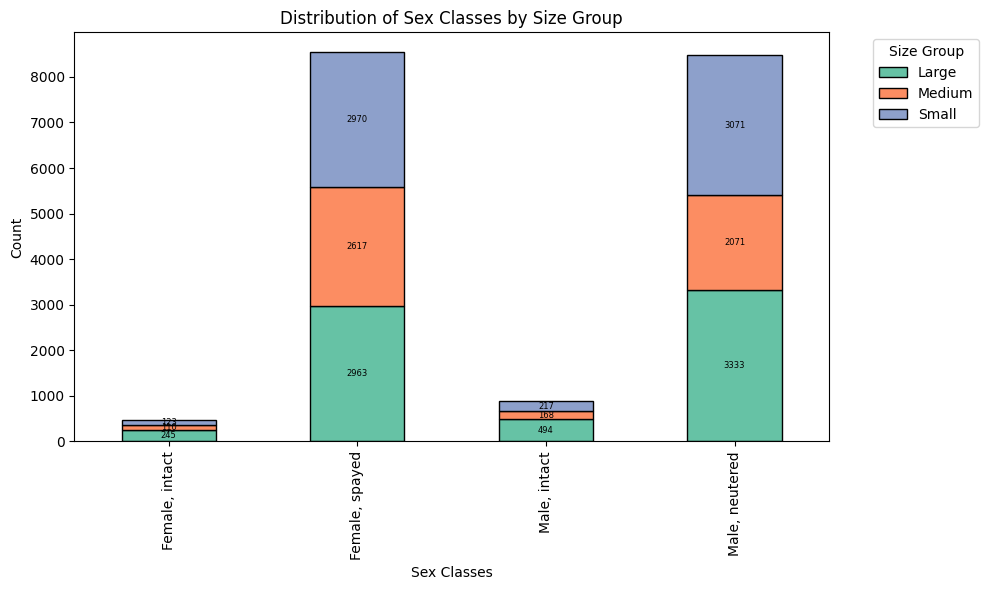

In [19]:
set2_palette = sns.color_palette("Set2", n_colors=3)

pivot_data = df_sex_size_copy.pivot_table(
    index='Sex_Class_at_HLES',
    columns='Size_Group',
    values='dog_id',
    aggfunc='count',  
    fill_value=0     
)

# stacked bar plot
pivot_data.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=set2_palette, 
    edgecolor='black'
)

# annotating each bar segment
for i, sex_class in enumerate(pivot_data.index):
    cumulative_height = 0  
    for size_group in pivot_data.columns:
        count = pivot_data.loc[sex_class, size_group]
        if count > 0:
            plt.text(
                x=i,  
                y=cumulative_height + count / 2,  # midpoint of bar segment
                s=f"{int(count)}",  
                ha='center', va='center', fontsize=6, color="black" 
            )
            cumulative_height += count

plt.xlabel("Sex Classes")
plt.ylabel("Count")
plt.title("Distribution of Sex Classes by Size Group")
plt.legend(title="Size Group", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("sex_distribution_by_size.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
#df_sex_size is dog_overview filtered to only large/medium/small. df_sex_size_copy has column size_group with value labels large/medium small

large_female_intact = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Large") & (df_sex_size_copy['Sex_Class_at_HLES']=="Female, intact")]
medium_female_intact = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Medium") & (df_sex_size_copy['Sex_Class_at_HLES']=="Female, intact")]
small_female_intact = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Small") & (df_sex_size_copy['Sex_Class_at_HLES']=="Female, intact")]

large_female_spayed = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Large") & (df_sex_size_copy['Sex_Class_at_HLES']=="Female, spayed")]
medium_female_spayed = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Medium") & (df_sex_size_copy['Sex_Class_at_HLES']=="Female, spayed")]
small_female_spayed = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Small") & (df_sex_size_copy['Sex_Class_at_HLES']=="Female, spayed")]

large_male_intact = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Large") & (df_sex_size_copy['Sex_Class_at_HLES']=="Male, intact")]
medium_male_intact = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Medium") & (df_sex_size_copy['Sex_Class_at_HLES']=="Male, intact")]
small_male_intact = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Small") & (df_sex_size_copy['Sex_Class_at_HLES']=="Male, intact")]

large_male_neutered = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Large") & (df_sex_size_copy['Sex_Class_at_HLES']=="Male, neutered")]
medium_male_neutered = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Medium") & (df_sex_size_copy['Sex_Class_at_HLES']=="Male, neutered")]
small_male_neutered = df_sex_size_copy[(df_sex_size_copy['Size_Group']=="Small") & (df_sex_size_copy['Sex_Class_at_HLES']=="Male, neutered")]

# check if numbers match table above. it does 
print(len(large_female_intact))
print(len(medium_female_intact))
print(len(small_female_intact))

print(len(large_male_intact))
print(len(medium_male_intact))
print(len(small_male_intact))

245
110
123
494
168
217


In [21]:
# exact balancing numbers for each (Size_Group, Sex_Class_at_HLES) combination
target_counts = {
    ("Large", "Female, intact"): 16,
    ("Large", "Female, spayed"): 32,
    ("Large", "Male, intact"): 45,
    ("Large", "Male, neutered"): 90, 
    ("Medium", "Female, intact"): 34,
    ("Medium", "Female, spayed"): 68,
    ("Medium", "Male, intact"): 36,
    ("Medium", "Male, neutered"): 72,
    ("Small", "Female, intact"): 35,
    ("Small", "Female, spayed"): 70,
    ("Small", "Male, intact"): 59,
    ("Small", "Male, neutered"): 118,
}

balanced_subsets = []

# interating over each sex/size combination
for (size, sex_class), group in df_sex_size_copy.groupby(["Size_Group", "Sex_Class_at_HLES"]):
    target_count = target_counts.get((size, sex_class), None)
    
    if target_count is None:
        continue  # skip if not in target counts
    
    # separate pure and mixed breed dogs
    akc_dogs = group[group["Breed_Class"] == "AKC-Recognized Breed"]
    mixed_dogs = group[group["Breed_Class"] == "Non-AKC-Recognized or Mixed Breed"]
    akc_sampled = akc_dogs.sample(n=min(len(akc_dogs), target_count), random_state=42)
    mixed_sampled = mixed_dogs.sample(n=min(len(mixed_dogs), target_count), random_state=42)

    balanced_subset = pd.concat([akc_sampled, mixed_sampled])
    balanced_subsets.append(balanced_subset)

df_balanced = pd.concat(balanced_subsets).reset_index(drop=True)
print(df_balanced.groupby(["Size_Group", "Sex_Class_at_HLES", "Breed_Class"]).size())

Size_Group  Sex_Class_at_HLES  Breed_Class                      
Large       Female, intact     AKC-Recognized Breed                  16
                               Non-AKC-Recognized or Mixed Breed     16
            Female, spayed     AKC-Recognized Breed                  32
                               Non-AKC-Recognized or Mixed Breed     32
            Male, intact       AKC-Recognized Breed                  45
                               Non-AKC-Recognized or Mixed Breed     45
            Male, neutered     AKC-Recognized Breed                  90
                               Non-AKC-Recognized or Mixed Breed     90
Medium      Female, intact     AKC-Recognized Breed                  34
                               Non-AKC-Recognized or Mixed Breed     34
            Female, spayed     AKC-Recognized Breed                  68
                               Non-AKC-Recognized or Mixed Breed     68
            Male, intact       AKC-Recognized Breed                  36

# Logistic Regression: Sex, Size, & Age (1-way, 2-way, and 3-way)

In [22]:
df_sex_size_regression = pd.merge(
    df_balanced[['dog_id', 'Size_Group', 'Sex_Class_at_HLES', 'Estimated_Age_Years_at_HLES']],
    health_conditions[['dog_id', 'hs_condition']],
    on='dog_id',
    how='inner'
)

sex_mapping = {
    "Female, intact": "Female_intact",
    "Female, spayed": "Female_spayed",
    "Male, intact": "Male_intact",
    "Male, neutered": "Male_neutered"
}
df_sex_size_regression['Sex_Class'] = df_sex_size_regression['Sex_Class_at_HLES'].map(sex_mapping)
df_sex_size_regression['Health_Condition'] = df_sex_size_regression['hs_condition'].map(hs_condition_dict)

df_sex_size_regression = df_sex_size_regression[
    df_sex_size_regression['Health_Condition'].isin(top_49_health_conditions)
]

df_sex_size_wide = pd.get_dummies(
    df_sex_size_regression,
    columns=['Health_Condition'],
    prefix='',
    prefix_sep=''
).groupby('dog_id').max().reset_index()

df_sex_size_wide['Sex_Class_Binary'] = df_sex_size_wide['Sex_Class'].map(lambda x: 3 if x == 'Male_neutered' else (2 if x == 'Male_intact' else (1 if x == 'Female_spayed' else 0)))
df_sex_size_wide['Age'] = df_sex_size_wide['Estimated_Age_Years_at_HLES']
size_numeric_mapping = {"Small": 1, "Medium": 2, "Large": 3}
df_sex_size_wide['Size_Class_Numeric'] = df_sex_size_wide['Size_Group'].map(size_numeric_mapping)

results_summary = []
failed_conditions = []

# logistic regression loop
for condition in top_49_health_conditions:
    if condition == "Tracheal collapse":
        print(f"Skipping {condition} - explicitly excluded")
        continue  # skip this condition explicitly cuz it's giving weird numbers
    if condition not in df_sex_size_wide.columns:
        print(f"Skipping {condition} - column not found in df_sex_size_wide")
        continue  # skip missing conditions

    y = df_sex_size_wide[condition].astype(int)  # convert boolean to integer

    # skip conditions with too few positive cases
    if y.sum() < 10:
        print(f"Skipping {condition} - too few positive cases ({y.sum()} ones)")
        continue

    X = df_sex_size_wide[['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']].copy()
    X['Sex_Age'] = X['Sex_Class_Binary'] * X['Age']
    X['Sex_Size'] = X['Sex_Class_Binary'] * X['Size_Class_Numeric']
    X['Size_Age'] = X['Size_Class_Numeric'] * X['Age']
    X['Sex_Size_Age'] = X['Sex_Class_Binary'] * X['Size_Class_Numeric'] * X['Age'] 

    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    try:
        logit_model = sm.Logit(y, X)
        result = logit_model.fit(disp=0)

        p_values = result.pvalues
        coefficients = result.params
        conf_intervals = result.conf_int()

        results_summary.append({
            'Health_Condition': condition,
            'Term': 'Intercept',
            'Coefficient': coefficients['const'],
            'P-value': p_values['const'],
            'CI_lower': conf_intervals.loc['const', 0],
            'CI_upper': conf_intervals.loc['const', 1]
        })
        for term in ['Sex_Class_Binary', 'Age', 'Size_Class_Numeric', 'Sex_Age', 'Sex_Size', 'Size_Age', 'Sex_Size_Age']:
            results_summary.append({
                'Health_Condition': condition,
                'Term': term,
                'Coefficient': coefficients[term],
                'P-value': p_values[term],
                'CI_lower': conf_intervals.loc[term, 0],
                'CI_upper': conf_intervals.loc[term, 1]
            })

    except Exception as e:
        print(f"Model failed for {condition} due to error: {e}")
        failed_conditions.append(condition)


sig_level = 0.05/45 # 49 conditions minus 4
results_df = pd.DataFrame(results_summary)
results_df['Significant'] = results_df['P-value'] < sig_level

results_df['Coefficient'] = results_df.apply(
    lambda row: f"<b>{row['Coefficient']:.4f}</b>" if row['Significant'] else f"{row['Coefficient']:.4f}", axis=1
)
results_df['P-value'] = results_df.apply(
    lambda row: f"<b>{row['P-value']:.4f}</b>" if row['Significant'] else f"{row['P-value']:.4f}", axis=1
)

column_order = ['Intercept', 'Sex_Class_Binary', 'Size_Class_Numeric', 'Age', 'Sex_Size', 'Sex_Age', 'Size_Age', 'Sex_Size_Age']
pivot_table = results_df.pivot(
    index='Health_Condition',
    columns='Term',
    values=['Coefficient', 'P-value', 'CI_lower', 'CI_upper']
)
pivot_table = pivot_table.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
pivot_table = pivot_table[column_order]


html_table = pivot_table.to_html(escape=False)
display(HTML(html_table))

Skipping Stenotic/narrow nares - too few positive cases (5 ones)
Skipping Tracheal collapse - explicitly excluded
Skipping Chronic kidney disease - too few positive cases (5 ones)
Skipping Entropion (eyelid rolled in) - too few positive cases (1 ones)


In [23]:
# excel_path = "logistic_regression_results.xlsx"

# # saving pivot table to an Excel file
# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     pivot_table.to_excel(writer, sheet_name="Pivot_Table")

#     workbook = writer.book
#     sheet = workbook.active

#     # applying bold formatting where necessary
#     for row_idx, row in enumerate(sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=2, max_col=sheet.max_column), start=2):
#         for cell in row:
#             if isinstance(cell.value, str) and "<b>" in cell.value:  
#                 cell.value = float(cell.value.replace("<b>", "").replace("</b>", ""))  # removing HTML tags
#                 cell.font = Font(bold=True)

#     workbook.save(excel_path)

# print(f"Formatted pivot table saved to {excel_path}")

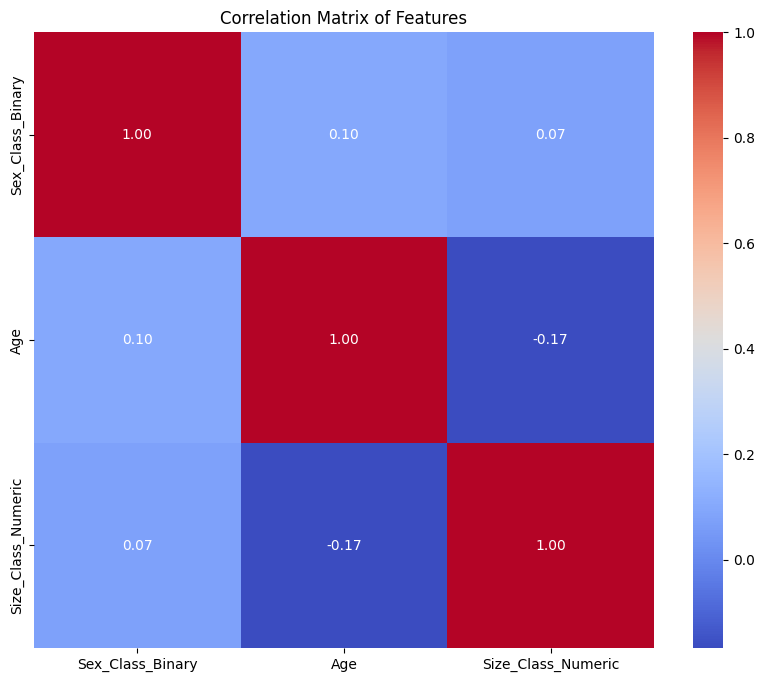

In [24]:
correlation_matrix = df_sex_size_wide[['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Logistic Regression: Sex, Size, & Age (1-way and 2-way)

In [25]:
results_summary_2 = []
failed_conditions_2 = []

# logistic regression loop
for condition in top_49_health_conditions:
    if condition == "Tracheal collapse":
        print(f"Skipping {condition} - explicitly excluded")
        continue  # skip this condition explicitly cuz it's giving weird numbers
    if condition not in df_sex_size_wide.columns:
        print(f"Skipping {condition} - column not found in df_sex_size_wide")
        continue  # skip missing conditions

    y = df_sex_size_wide[condition].astype(int)  # convert boolean to integer

    # skip conditions with too few positive cases
    if y.sum() < 10:
        print(f"Skipping {condition} - too few positive cases ({y.sum()} ones)")
        continue

    X = df_sex_size_wide[['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']].copy()
    X['Sex_Age'] = X['Sex_Class_Binary'] * X['Age']
    X['Sex_Size'] = X['Sex_Class_Binary'] * X['Size_Class_Numeric']
    X['Size_Age'] = X['Size_Class_Numeric'] * X['Age']

    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    try:
        logit_model_2 = sm.Logit(y, X)
        result_2 = logit_model_2.fit(disp=0)

        p_values = result_2.pvalues
        coefficients = result_2.params
        conf_intervals = result_2.conf_int()

        results_summary_2.append({
            'Health_Condition': condition,
            'Term': 'Intercept',
            'Coefficient': coefficients['const'],
            'P-value': p_values['const'],
            'CI_lower': conf_intervals.loc['const', 0],
            'CI_upper': conf_intervals.loc['const', 1]
        })
        for term in ['Sex_Class_Binary', 'Age', 'Size_Class_Numeric', 'Sex_Age', 'Sex_Size', 'Size_Age']:
            results_summary_2.append({
                'Health_Condition': condition,
                'Term': term,
                'Coefficient': coefficients[term],
                'P-value': p_values[term],
                'CI_lower': conf_intervals.loc[term, 0],
                'CI_upper': conf_intervals.loc[term, 1]
            })

    except Exception as e:
        print(f"Model failed for {condition} due to error: {e}")
        failed_conditions_2.append(condition)

sig_level = 0.05/45 # 49 conditions minus 4
results_df_2 = pd.DataFrame(results_summary_2)
results_df_2['Significant'] = results_df_2['P-value'] < sig_level

results_df_2['Coefficient'] = results_df_2.apply(
    lambda row: f"<b>{row['Coefficient']:.4f}</b>" if row['Significant'] else f"{row['Coefficient']:.4f}", axis=1
)
results_df_2['P-value'] = results_df_2.apply(
    lambda row: f"<b>{row['P-value']:.4f}</b>" if row['Significant'] else f"{row['P-value']:.4f}", axis=1
)

column_order_2 = ['Intercept', 'Sex_Class_Binary', 'Size_Class_Numeric', 'Age', 'Sex_Size', 'Sex_Age', 'Size_Age']
pivot_table_2 = results_df_2.pivot(
    index='Health_Condition',
    columns='Term',
    values=['Coefficient', 'P-value', 'CI_lower', 'CI_upper']
)
pivot_table_2 = pivot_table_2.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
pivot_table_2 = pivot_table_2[column_order_2]


html_table_2 = pivot_table_2.to_html(escape=False)
display(HTML(html_table_2))

Skipping Stenotic/narrow nares - too few positive cases (5 ones)
Skipping Tracheal collapse - explicitly excluded
Skipping Chronic kidney disease - too few positive cases (5 ones)
Skipping Entropion (eyelid rolled in) - too few positive cases (1 ones)


In [26]:
print(result_2.mle_retvals)

{'fopt': np.float64(0.18673900414600902), 'iterations': 9, 'score': array([-5.81665822e-18, -3.03477820e-18, -7.08114913e-18,  1.06217237e-17,
       -5.56376003e-18, -3.03477820e-18, -7.58694550e-18]), 'Hessian': array([[-5.27144948e-02, -2.02055470e-03, -5.63218602e-02,
         2.09990418e-02, -3.81298217e-02,  1.19148537e-02,
        -2.67896272e-02],
       [-2.02055470e-03, -4.77054399e-02,  2.77439200e-04,
        -3.75286644e-04, -4.86199335e-02, -2.68405107e-02,
        -3.85283363e-05],
       [-5.63218602e-02,  2.77439200e-04, -8.67846705e-02,
         2.57682382e-02, -5.74202588e-02,  1.65500619e-02,
        -4.35449238e-02],
       [ 2.09990418e-02, -3.75286644e-04,  2.57682382e-02,
        -4.70244725e-02,  1.68682787e-02, -3.00444077e-02,
        -2.56808236e-02],
       [-3.81298217e-02, -4.86199335e-02, -5.74202588e-02,
         1.68682787e-02, -9.12470879e-02, -1.61233775e-02,
        -2.88967990e-02],
       [ 1.19148537e-02, -2.68405107e-02,  1.65500619e-02,
       

In [27]:
# excel_path = "logistic_regression_results_2.xlsx"

# # saving pivot table to an Excel file
# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     pivot_table_2.to_excel(writer, sheet_name="Pivot_Table")

#     workbook = writer.book
#     sheet = workbook.active

#     # applying bold formatting where necessary
#     for row_idx, row in enumerate(sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=2, max_col=sheet.max_column), start=2):
#         for cell in row:
#             if isinstance(cell.value, str) and "<b>" in cell.value:  
#                 cell.value = float(cell.value.replace("<b>", "").replace("</b>", ""))  # removing HTML tags
#                 cell.font = Font(bold=True)

#     workbook.save(excel_path)

# print(f"Formatted pivot table saved to {excel_path}")

# Logistic Regression: Sex, Size, & Age (1-way and 2x 2-way)

In [28]:
results_summary_3 = []
failed_conditions_3 = []

# logistic regression loop
for condition in top_49_health_conditions:
    if condition == "Tracheal collapse":
        print(f"Skipping {condition} - explicitly excluded")
        continue  # skip this condition explicitly cuz it's giving weird numbers
    if condition not in df_sex_size_wide.columns:
        print(f"Skipping {condition} - column not found in df_sex_size_wide")
        continue  # skip missing conditions

    y = df_sex_size_wide[condition].astype(int)  # convert boolean to integer

    # skip conditions with too few positive cases
    if y.sum() < 10:
        print(f"Skipping {condition} - too few positive cases ({y.sum()} ones)")
        continue

    X = df_sex_size_wide[['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']].copy()
    X['Sex_Size'] = X['Sex_Class_Binary'] * X['Size_Class_Numeric']
    X['Size_Age'] = X['Size_Class_Numeric'] * X['Age']

    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    try:
        logit_model_3 = sm.Logit(y, X)
        result_3 = logit_model_3.fit(disp=0)

        p_values = result_3.pvalues
        coefficients = result_3.params
        conf_intervals = result_3.conf_int()

        results_summary_3.append({
            'Health_Condition': condition,
            'Term': 'Intercept',
            'Coefficient': coefficients['const'],
            'P-value': p_values['const'],
            'CI_lower': conf_intervals.loc['const', 0],
            'CI_upper': conf_intervals.loc['const', 1]
        })
        for term in ['Sex_Class_Binary', 'Age', 'Size_Class_Numeric', 'Sex_Size', 'Size_Age']:
            results_summary_3.append({
                'Health_Condition': condition,
                'Term': term,
                'Coefficient': coefficients[term],
                'P-value': p_values[term],
                'CI_lower': conf_intervals.loc[term, 0],
                'CI_upper': conf_intervals.loc[term, 1]
            })

    except Exception as e:
        print(f"Model failed for {condition} due to error: {e}")
        failed_conditions_3.append(condition)

sig_level = 0.05/45
results_df_3 = pd.DataFrame(results_summary_3)
results_df_3['Significant'] = results_df_3['P-value'] < sig_level

results_df_3['Coefficient'] = results_df_3.apply(
    lambda row: f"<b>{row['Coefficient']:.4f}</b>" if row['Significant'] else f"{row['Coefficient']:.4f}", axis=1
)
results_df_3['P-value'] = results_df_3.apply(
    lambda row: f"<b>{row['P-value']:.4f}</b>" if row['Significant'] else f"{row['P-value']:.4f}", axis=1
)

column_order_3 = ['Intercept', 'Sex_Class_Binary', 'Size_Class_Numeric', 'Age', 'Sex_Size', 'Size_Age']
pivot_table_3 = results_df_3.pivot(
    index='Health_Condition',
    columns='Term',
    values=['Coefficient', 'P-value', 'CI_lower', 'CI_upper']
)
pivot_table_3 = pivot_table_3.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
pivot_table_3 = pivot_table_3[column_order_3]


html_table_3 = pivot_table_3.to_html(escape=False)
display(HTML(html_table_3))

Skipping Stenotic/narrow nares - too few positive cases (5 ones)
Skipping Tracheal collapse - explicitly excluded
Skipping Chronic kidney disease - too few positive cases (5 ones)
Skipping Entropion (eyelid rolled in) - too few positive cases (1 ones)


In [29]:
print(result_3.mle_retvals)

{'fopt': np.float64(0.18691510885384513), 'iterations': 9, 'score': array([ 3.41412547e-18, -3.03477820e-18,  1.77028728e-17, -5.56376003e-18,
        0.00000000e+00,  6.06955640e-18]), 'Hessian': array([[-0.05273343, -0.0010162 , -0.05629082,  0.02105449,  0.01247704,
        -0.02666693],
       [-0.0010162 , -0.04819725, -0.00055861, -0.00090217, -0.02739878,
        -0.00095184],
       [-0.05629082, -0.00055861, -0.08677898,  0.02593514,  0.01612584,
        -0.04330184],
       [ 0.02105449, -0.00090217,  0.02593514, -0.04706829, -0.03014398,
        -0.02564354],
       [ 0.01247704, -0.02739878,  0.01612584, -0.03014398, -0.03716604,
        -0.01643365],
       [-0.02666693, -0.00095184, -0.04330184, -0.02564354, -0.01643365,
        -0.06235815]]), 'warnflag': 0, 'converged': True}


In [30]:
# excel_path = "logistic_regression_results_3.xlsx"

# # saving pivot table to an Excel file
# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     pivot_table_3.to_excel(writer, sheet_name="Pivot_Table")

#     workbook = writer.book
#     sheet = workbook.active

#     # applying bold formatting where necessary
#     for row_idx, row in enumerate(sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=2, max_col=sheet.max_column), start=2):
#         for cell in row:
#             if isinstance(cell.value, str) and "<b>" in cell.value:  
#                 cell.value = float(cell.value.replace("<b>", "").replace("</b>", ""))  # removing HTML tags
#                 cell.font = Font(bold=True)

#     workbook.save(excel_path)

# print(f"Formatted pivot table saved to {excel_path}")

# Logistic Regression: Sex, Size, & Age (1-way and 1x 2-way)

In [31]:
results_summary_4 = []
failed_conditions_4 = []

# logistic regression loop
for condition in top_49_health_conditions:
    if condition == "Tracheal collapse":
        print(f"Skipping {condition} - explicitly excluded")
        continue  # skip this condition explicitly cuz it's giving weird numbers
    if condition not in df_sex_size_wide.columns:
        print(f"Skipping {condition} - column not found in df_sex_size_wide")
        continue  # skip missing conditions

    y = df_sex_size_wide[condition].astype(int)  # convert boolean to integer

    # skip conditions with too few positive cases
    if y.sum() < 10:
        print(f"Skipping {condition} - too few positive cases ({y.sum()} ones)")
        continue

    X = df_sex_size_wide[['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']].copy()
    X['Sex_Size'] = X['Sex_Class_Binary'] * X['Size_Class_Numeric']

    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    try:
        logit_model_4 = sm.Logit(y, X)
        result_4 = logit_model_4.fit(disp=0)

        p_values = result_4.pvalues
        coefficients = result_4.params
        conf_intervals = result_4.conf_int()

        results_summary_4.append({
            'Health_Condition': condition,
            'Term': 'Intercept',
            'Coefficient': coefficients['const'],
            'P-value': p_values['const'],
            'CI_lower': conf_intervals.loc['const', 0],
            'CI_upper': conf_intervals.loc['const', 1]
        })
        for term in ['Sex_Class_Binary', 'Age', 'Size_Class_Numeric', 'Sex_Size']:
            results_summary_4.append({
                'Health_Condition': condition,
                'Term': term,
                'Coefficient': coefficients[term],
                'P-value': p_values[term],
                'CI_lower': conf_intervals.loc[term, 0],
                'CI_upper': conf_intervals.loc[term, 1]
            })

    except Exception as e:
        print(f"Model failed for {condition} due to error: {e}")
        failed_conditions_4.append(condition)

sig_level = 0.05/45
results_df_4 = pd.DataFrame(results_summary_4)
results_df_4['Significant'] = results_df_4['P-value'] < sig_level

results_df_4['Coefficient'] = results_df_4.apply(
    lambda row: f"<b>{row['Coefficient']:.2e}</b>" if row['Significant'] else f"{row['Coefficient']:.2e}", axis=1
)
results_df_4['P-value'] = results_df_4.apply(
    lambda row: f"<b>{row['P-value']:.2e}</b>" if row['Significant'] else f"{row['P-value']:.2e}", axis=1
)

column_order_4 = ['Intercept', 'Sex_Class_Binary', 'Size_Class_Numeric', 'Age', 'Sex_Size']
pivot_table_4 = results_df_4.pivot(
    index='Health_Condition',
    columns='Term',
    values=['Coefficient', 'P-value', 'CI_lower', 'CI_upper']
)
pivot_table_4 = pivot_table_4.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
pivot_table_4 = pivot_table_4[column_order_4]


html_table_4 = pivot_table_4.to_html(escape=False)
display(HTML(html_table_4))

Skipping Stenotic/narrow nares - too few positive cases (5 ones)
Skipping Tracheal collapse - explicitly excluded
Skipping Chronic kidney disease - too few positive cases (5 ones)
Skipping Entropion (eyelid rolled in) - too few positive cases (1 ones)


In [32]:
# excel_path = "logistic_regression_results_4.xlsx"

# # saving pivot table to an Excel file
# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     pivot_table_4.to_excel(writer, sheet_name="Pivot_Table")

#     workbook = writer.book
#     sheet = workbook.active

#     # applying bold formatting where necessary
#     for row_idx, row in enumerate(sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=2, max_col=sheet.max_column), start=2):
#         for cell in row:
#             if isinstance(cell.value, str) and "<b>" in cell.value:  
#                 cell.value = float(cell.value.replace("<b>", "").replace("</b>", ""))  # removing HTML tags
#                 cell.font = Font(bold=True)

#     workbook.save(excel_path)

# print(f"Formatted pivot table saved to {excel_path}")

# Logistic Regression: Sex, Size, & Age (1-way)

In [33]:
results_summary_5 = []
failed_conditions_5 = []

# logistic regression loop
for condition in top_49_health_conditions:
    if condition == "Tracheal collapse":
        print(f"Skipping {condition} - explicitly excluded")
        continue  # skip this condition explicitly cuz it's giving weird numbers
    if condition not in df_sex_size_wide.columns:
        print(f"Skipping {condition} - column not found in df_sex_size_wide")
        continue  # skip missing conditions

    y = df_sex_size_wide[condition].astype(int)  # convert boolean to integer

    # skip conditions with too few positive cases
    if y.sum() < 10:
        print(f"Skipping {condition} - too few positive cases ({y.sum()} ones)")
        continue

    X = df_sex_size_wide[['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']].copy()

    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    try:
        logit_model_5 = sm.Logit(y, X)
        result_5 = logit_model_5.fit(disp=0)

        p_values = result_5.pvalues
        coefficients = result_5.params
        conf_intervals = result_5.conf_int()

        results_summary_5.append({
            'Health_Condition': condition,
            'Term': 'Intercept',
            'Coefficient': coefficients['const'],
            'P-value': p_values['const'],
            'CI_lower': conf_intervals.loc['const', 0],
            'CI_upper': conf_intervals.loc['const', 1]
        })
        for term in ['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']:
            results_summary_5.append({
                'Health_Condition': condition,
                'Term': term,
                'Coefficient': coefficients[term],
                'P-value': p_values[term],
                'CI_lower': conf_intervals.loc[term, 0],
                'CI_upper': conf_intervals.loc[term, 1]
            })

    except Exception as e:
        print(f"Model failed for {condition} due to error: {e}")
        failed_conditions_5.append(condition)

sig_level = 0.05/45
results_df_5 = pd.DataFrame(results_summary_5)
results_df_5['Significant'] = results_df_5['P-value'] < sig_level

# use .2e for scientific notation, .4f for decimal notation 
results_df_5['Coefficient'] = results_df_5.apply(
    lambda row: f"<b>{row['Coefficient']:.2e}</b>" if row['Significant'] else f"{row['Coefficient']:.2e}", axis=1
)
results_df_5['P-value'] = results_df_5.apply(
    lambda row: f"<b>{row['P-value']:.2e}</b>" if row['Significant'] else f"{row['P-value']:.2e}", axis=1
)

column_order_5 = ['Intercept', 'Sex_Class_Binary', 'Size_Class_Numeric', 'Age']
pivot_table_5 = results_df_5.pivot(
    index='Health_Condition',
    columns='Term',
    values=['Coefficient', 'P-value', 'CI_lower', 'CI_upper']
)
pivot_table_5 = pivot_table_5.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
pivot_table_5 = pivot_table_5[column_order_5]


html_table_5 = pivot_table_5.to_html(escape=False)
display(HTML(html_table_5))

Skipping Stenotic/narrow nares - too few positive cases (5 ones)
Skipping Tracheal collapse - explicitly excluded
Skipping Chronic kidney disease - too few positive cases (5 ones)
Skipping Entropion (eyelid rolled in) - too few positive cases (1 ones)


In [34]:
# excel_path = "logistic_regression_results_5.xlsx"

# # saving pivot table to an Excel file
# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     pivot_table_5.to_excel(writer, sheet_name="Pivot_Table")

#     workbook = writer.book
#     sheet = workbook.active

#     # applying bold formatting where necessary
#     for row_idx, row in enumerate(sheet.iter_rows(min_row=2, max_row=sheet.max_row, min_col=2, max_col=sheet.max_column), start=2):
#         for cell in row:
#             if isinstance(cell.value, str) and "<b>" in cell.value:  
#                 cell.value = float(cell.value.replace("<b>", "").replace("</b>", ""))  # removing HTML tags
#                 cell.font = Font(bold=True)

#     workbook.save(excel_path)

# print(f"Formatted pivot table saved to {excel_path}")

In [35]:
significant_results = results_df_5[
    (results_df_5['Significant']) & (results_df_5['Term'] != "Intercept")
]
significant_results.loc[:, 'Term'] = significant_results['Term'].replace('Size_Class_Numeric', 'Size')

# mapping of health conditions to their significant predictors
final_predictors = significant_results.groupby('Health_Condition')['Term'].apply(
    lambda x: ', '.join(sorted(x))
).reset_index()

final_predictors.columns = ['Health Condition', 'Significant Predictors']
html_table_sig = final_predictors.to_html(index=False)
display(HTML(html_table_sig))

# saving to excel file
# excel_path = "final_predictors.xlsx"

# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     final_predictors.to_excel(writer, sheet_name="Results", index=False)

#     workbook = writer.book
#     sheet = workbook.active
#     workbook.save(excel_path)

# print(f"Formatted Excel file saved to {excel_path}")

Health Condition,Significant Predictors
Cataracts,Age
Cruciate ligament rupture,Age
Deafness,Age
Dental calculus (yellow build-up on teeth),"Age, Size"
Dog bite,Age
Ear Infection,Size
Extracted teeth,"Age, Size"
"Gingivitis (red, puffy gums)",Age
Hearing loss (incompletely deaf),Age
Murmur,Age


# lasso regression (test)

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

results_summary_lasso = []
failed_conditions_lasso = []

# logistic regression loop with LASSO
for condition in top_49_health_conditions:
    if condition == "Tracheal collapse":
        print(f"Skipping {condition} - explicitly excluded")
        continue  # skip this condition explicitly cuz it's giving weird numbers
    if condition not in df_sex_size_wide.columns:
        print(f"Skipping {condition} - column not found in df_sex_size_wide")
        continue

    y = df_sex_size_wide[condition].astype(int)  # convert boolean to integer

    if y.sum() < 10:
        print(f"Skipping {condition} - too few positive cases ({y.sum()} ones)")
        continue

    X = df_sex_size_wide[['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']].copy()
    X['Sex_Age'] = X['Sex_Class_Binary'] * X['Age']
    X['Sex_Size'] = X['Sex_Class_Binary'] * X['Size_Class_Numeric']
    X['Size_Age'] = X['Size_Class_Numeric'] * X['Age']

    # standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    try:
        # fit LASSO logistic regression (L1 penalty)
        lasso_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)  # C controls regularization strength
        lasso_model.fit(X_scaled, y)

        # extract coefficients
        coefficients = lasso_model.coef_[0]
        feature_names = ['Intercept'] + list(X.columns)
        
        for feature, coef in zip(feature_names[1:], coefficients):  # skip intercept
            results_summary_lasso.append({
                'Health_Condition': condition,
                'Term': feature,
                'Coefficient': coef,
                'Selected': coef != 0  # true if LASSO kept this term
            })

    except Exception as e:
        print(f"Model failed for {condition} due to error: {e}")
        failed_conditions_lasso.append(condition)

column_order_lasso = ['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']

results_df_lasso = pd.DataFrame(results_summary_lasso)
pivot_table_lasso = results_df_lasso.pivot(
    index='Health_Condition',
    columns='Term',
    values='Coefficient'
)
pivot_table_lasso = pivot_table_lasso[column_order_lasso]
pivot_table_lasso = pivot_table_lasso.rename(columns={
    'Sex_Class_Binary': 'Sex Class',
    'Age': 'Age',
    'Size_Class_Numeric': 'Size'
})

display(HTML(pivot_table_lasso.to_html(escape=False))) # positive coefficient = positive correlation

Skipping Stenotic/narrow nares - too few positive cases (5 ones)
Skipping Tracheal collapse - explicitly excluded
Skipping Chronic kidney disease - too few positive cases (5 ones)
Skipping Entropion (eyelid rolled in) - too few positive cases (1 ones)


Term,Sex Class,Age,Size
Health_Condition,,,
Anal sac impaction,0.000000,0.000000,0.000000
Bordetella and/or parainfluenza (kennel cough),0.000000,-0.048203,0.102885
Cataracts,0.000000,1.046269,-0.085145
Chocolate,0.081559,0.000000,0.000000
Chronic or recurrent diarrhea,0.000000,-0.038099,0.000000
Chronic or recurrent hot spots,0.000000,0.000000,0.000000
Coccidia,0.000000,-0.121041,0.000000
Conjunctivitis,0.000000,-0.068012,0.000000
Corneal ulcer,0.000000,0.127714,0.000000


In [48]:
# excel_path = "lasso_regression_results.xlsx"

# # saving pivot table to an Excel file
# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     pivot_table_lasso.to_excel(writer, sheet_name="Pivot_Table")

#     workbook = writer.book
#     sheet = workbook.active

#     workbook.save(excel_path)

# print(f"Formatted pivot table saved to {excel_path}")

Formatted pivot table saved to lasso_regression_results.xlsx


# data balancing without male/female, only neutered/intact. test blocks

In [37]:
df_sex_size_2 = df_sex_size.copy()

# map size classes to broader categories (small, medium, large)
size_mapping = {
    "Large AKC-recognized purebred dogs": "Large",
    "Large non-AKC and mixed breed dogs": "Large",
    "Medium AKC-recognized purebred dogs": "Medium",
    "Medium non-AKC and mixed breed dogs": "Medium",
    "Toy and Small AKC-recognized purebred dogs": "Small",
    "Toy and Small non-AKC and mixed breed dogs": "Small"
}
sex_mapping = {
    "Female, intact": "Intact",
    "Male, intact": "Intact",
    "Female, spayed": "Neutered",
    "Male, neutered": "Neutered"
}

df_sex_size_2['Size_Group'] = df_sex_size_2['Breed_Size_Class_at_HLES'].map(size_mapping) 
df_sex_size_2['Sex_Group'] = df_sex_size_2['Sex_Class_at_HLES'].map(sex_mapping) 

# calculate percentages within each size group and sex class
breed_distribution_2 = df_sex_size_2.groupby(['Size_Group', 'Sex_Group', 'Breed_Class']).size().reset_index(name='Count')
total_counts_2 = breed_distribution_2.groupby(['Size_Group', 'Sex_Group'])['Count'].transform('sum')
breed_distribution_2['Percentage'] = (breed_distribution_2['Count'] / total_counts_2) * 100

# pivot data for readability
pivot_breed_dist_2 = breed_distribution_2.pivot_table(
    index=['Size_Group', 'Sex_Group'], 
    columns='Breed_Class', 
    values=['Count', 'Percentage'], 
    fill_value=0
)

pivot_breed_dist_2

Count                                             Percentage                                  
Breed_Class          AKC-Recognized Breed Non-AKC-Recognized or Mixed Breed AKC-Recognized Breed Non-AKC-Recognized or Mixed Breed
Size_Group Sex_Group                                                                                                              
Large      Intact                   678.0                              61.0            91.745602                          8.254398
           Neutered                3976.0                            2320.0            63.151207                         36.848793
Medium     Intact                   208.0                              70.0            74.820144                         25.179856
           Neutered                1601.0                            3087.0            34.151024                         65.848976
Small      Intact                   246.0                              94.0            72.352941                         27.647059
           Neutered                3140.0                            2901.0            51.978149                         48.021851

In [38]:
# sorting by neutered or not, irregardless of male or female
large_intact = df_sex_size_2[(df_sex_size_2['Size_Group']=="Large") & (df_sex_size_2['Sex_Group']=="Intact")]
medium_intact = df_sex_size_2[(df_sex_size_2['Size_Group']=="Medium") & (df_sex_size_2['Sex_Group']=="Intact")]
small_intact = df_sex_size_2[(df_sex_size_2['Size_Group']=="Small") & (df_sex_size_2['Sex_Group']=="Intact")]
large_neutered = df_sex_size_2[(df_sex_size_2['Size_Group']=="Large") & (df_sex_size_2['Sex_Group']=="Neutered")]
medium_neutered = df_sex_size_2[(df_sex_size_2['Size_Group']=="Medium") & (df_sex_size_2['Sex_Group']=="Neutered")]
small_neutered = df_sex_size_2[(df_sex_size_2['Size_Group']=="Small") & (df_sex_size_2['Sex_Group']=="Neutered")]

# check if numbers match table above. it does 
print(len(large_intact))
print(len(medium_intact))
print(len(small_intact))

print(len(large_neutered))
print(len(medium_neutered))
print(len(small_neutered))

739
278
340
6296
4688
6041


In [39]:
# exact balancing numbers for each (Size_Group, Sex_Class_at_HLES) combination
target_counts_2 = {
    ("Large", "Intact"): 61,
    ("Large", "Neutered"): 61,
    ("Medium", "Intact"): 70,
    ("Medium", "Neutered"): 70,
    ("Small", "Intact"): 94,
    ("Small", "Neutered"): 94,
}

balanced_subsets_2 = []

# interating over each sex/size combination
for (size, sex_class), group in df_sex_size_2.groupby(["Size_Group", "Sex_Group"]):
    target_count_2 = target_counts_2.get((size, sex_class), None)
    
    if target_count_2 is None:
        continue  # skip if not in target counts
    
    # separate pure and mixed breed dogs
    akc_dogs_2 = group[group["Breed_Class"] == "AKC-Recognized Breed"]
    mixed_dogs_2 = group[group["Breed_Class"] == "Non-AKC-Recognized or Mixed Breed"]
    akc_sampled_2 = akc_dogs_2.sample(n=min(len(akc_dogs_2), target_count_2), random_state=43)
    mixed_sampled_2 = mixed_dogs_2.sample(n=min(len(mixed_dogs_2), target_count_2), random_state=43)

    balanced_subset_2 = pd.concat([akc_sampled_2, mixed_sampled_2])
    balanced_subsets_2.append(balanced_subset_2)

df_balanced_2 = pd.concat(balanced_subsets_2).reset_index(drop=True)
print(df_balanced_2.groupby(["Size_Group", "Sex_Group", "Breed_Class"]).size())

Size_Group  Sex_Group  Breed_Class                      
Large       Intact     AKC-Recognized Breed                 61
                       Non-AKC-Recognized or Mixed Breed    61
            Neutered   AKC-Recognized Breed                 61
                       Non-AKC-Recognized or Mixed Breed    61
Medium      Intact     AKC-Recognized Breed                 70
                       Non-AKC-Recognized or Mixed Breed    70
            Neutered   AKC-Recognized Breed                 70
                       Non-AKC-Recognized or Mixed Breed    70
Small       Intact     AKC-Recognized Breed                 94
                       Non-AKC-Recognized or Mixed Breed    94
            Neutered   AKC-Recognized Breed                 94
                       Non-AKC-Recognized or Mixed Breed    94
dtype: int64


In [40]:
df_sex_size_regression_a = pd.merge(
    df_balanced_2[['dog_id', 'Size_Group', 'Sex_Group', 'Estimated_Age_Years_at_HLES']],
    health_conditions[['dog_id', 'hs_condition']],
    on='dog_id',
    how='inner'
)

df_sex_size_regression_a['Health_Condition'] = df_sex_size_regression_a['hs_condition'].map(hs_condition_dict)

df_sex_size_regression_a = df_sex_size_regression_a[
    df_sex_size_regression_a['Health_Condition'].isin(top_49_health_conditions)]

df_sex_size_wide_a = pd.get_dummies(
    df_sex_size_regression_a,
    columns=['Health_Condition'],
    prefix='',
    prefix_sep=''
).groupby('dog_id').max().reset_index()

df_sex_size_wide_a['Sex_Class_Binary'] = df_sex_size_wide_a['Sex_Group'].map(lambda x: 1 if x == 'Neutered' else 0)
df_sex_size_wide_a['Age'] = df_sex_size_wide_a['Estimated_Age_Years_at_HLES']
size_numeric_mapping = {"Small": 1, "Medium": 2, "Large": 3}
df_sex_size_wide_a['Size_Class_Numeric'] = df_sex_size_wide_a['Size_Group'].map(size_numeric_mapping)

results_summary_a = []
failed_conditions_a = []

# logistic regression loop
for condition in top_49_health_conditions:
    if condition == "Tracheal collapse":
        print(f"Skipping {condition} - explicitly excluded")
        continue  # skip this condition explicitly cuz it's giving weird numbers
    if condition not in df_sex_size_wide_a.columns:
        print(f"Skipping {condition} - column not found in df_sex_size_wide_a")
        continue  # skip missing conditions

    y = df_sex_size_wide_a[condition].astype(int)  # convert boolean to integer

    # skip conditions with too few positive cases
    if y.sum() < 10:
        print(f"Skipping {condition} - too few positive cases ({y.sum()} ones)")
        continue

    X = df_sex_size_wide_a[['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']].copy()
    X['Sex_Age'] = X['Sex_Class_Binary'] * X['Age']
    X['Sex_Size'] = X['Sex_Class_Binary'] * X['Size_Class_Numeric']
    X['Size_Age'] = X['Size_Class_Numeric'] * X['Age']
    X['Sex_Size_Age'] = X['Sex_Class_Binary'] * X['Size_Class_Numeric'] * X['Age'] 

    X = (X - X.mean()) / X.std()
    X = sm.add_constant(X)

    try:
        logit_model_a = sm.Logit(y, X)
        result_a = logit_model_a.fit(disp=0)

        p_values = result_a.pvalues
        coefficients = result_a.params
        conf_intervals = result_a.conf_int()

        results_summary_a.append({
            'Health_Condition': condition,
            'Term': 'Intercept',
            'Coefficient': coefficients['const'],
            'P-value': p_values['const'],
            'CI_lower': conf_intervals.loc['const', 0],
            'CI_upper': conf_intervals.loc['const', 1]
        })
        for term in ['Sex_Class_Binary', 'Age', 'Size_Class_Numeric']:
            results_summary_a.append({
                'Health_Condition': condition,
                'Term': term,
                'Coefficient': coefficients[term],
                'P-value': p_values[term],
                'CI_lower': conf_intervals.loc[term, 0],
                'CI_upper': conf_intervals.loc[term, 1]
            })

    except Exception as e:
        print(f"Model failed for {condition} due to error: {e}")
        failed_conditions_a.append(condition)

sig_level=0.05/45
results_df_a = pd.DataFrame(results_summary_a)
results_df_a['Significant'] = results_df_a['P-value'] < sig_level

results_df_a['Coefficient'] = results_df_a.apply(
    lambda row: f"<b>{row['Coefficient']:.4f}</b>" if row['Significant'] else f"{row['Coefficient']:.4f}", axis=1
)
results_df_a['P-value'] = results_df_a.apply(
    lambda row: f"<b>{row['P-value']:.4f}</b>" if row['Significant'] else f"{row['P-value']:.4f}", axis=1
)

column_order = ['Intercept', 'Sex_Class_Binary', 'Size_Class_Numeric', 'Age']
pivot_table_a = results_df_a.pivot(
    index='Health_Condition',
    columns='Term',
    values=['Coefficient', 'P-value', 'CI_lower', 'CI_upper']
)
pivot_table_a = pivot_table_a.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
pivot_table_a = pivot_table_a[column_order]


html_table_a = pivot_table_a.to_html(escape=False)
display(HTML(html_table_a))

Skipping Stenotic/narrow nares - too few positive cases (2 ones)
Skipping Tracheal collapse - explicitly excluded
Skipping Chronic kidney disease - too few positive cases (6 ones)
Skipping Hip dysplasia - too few positive cases (7 ones)
Skipping Corneal ulcer - too few positive cases (9 ones)
Skipping Lick granuloma - too few positive cases (3 ones)
Skipping Entropion (eyelid rolled in) - too few positive cases (1 ones)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

In [41]:
print(result_a.mle_retvals)

{'fopt': np.float64(0.1432434843890026), 'iterations': 10, 'score': array([-4.77292141e-18, -3.94284812e-18, -6.01803135e-18,  1.66014658e-18,
        3.52781148e-18, -4.15036645e-19, -1.20879423e-17, -7.67817793e-18]), 'Hessian': array([[-0.04028115,  0.00327586, -0.04859563,  0.01802042, -0.01953985,
         0.00936184, -0.02533377, -0.00931971],
       [ 0.00327586, -0.04156802, -0.00289436, -0.00467938, -0.05092917,
        -0.02856165, -0.00491829, -0.03903844],
       [-0.04859563, -0.00289436, -0.07794819,  0.02119468, -0.03981414,
         0.00784201, -0.04255139, -0.02111399],
       [ 0.01802042, -0.00467938,  0.02119468, -0.03696996,  0.00601079,
        -0.0187692 , -0.02078511, -0.01530756],
       [-0.01953985, -0.05092917, -0.03981414,  0.00601079, -0.08271345,
        -0.02981876, -0.02422668, -0.05792894],
       [ 0.00936184, -0.02856165,  0.00784201, -0.0187692 , -0.02981876,
        -0.0299561 , -0.01187962, -0.03658232],
       [-0.02533377, -0.00491829, -0.042551